In [17]:
from sklearn.datasets import fetch_lfw_people

lfw = fetch_lfw_people(
    min_faces_per_person=70,
    resize=0.4
)

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [27]:
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

X = lfw.images
y = lfw.target
target_names = lfw.target_names

print("Dataset Shape:", X.shape)
print("Number of Classes:", len(target_names))
print(target_names)

Dataset Shape: (1288, 50, 37)
Number of Classes: 7
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


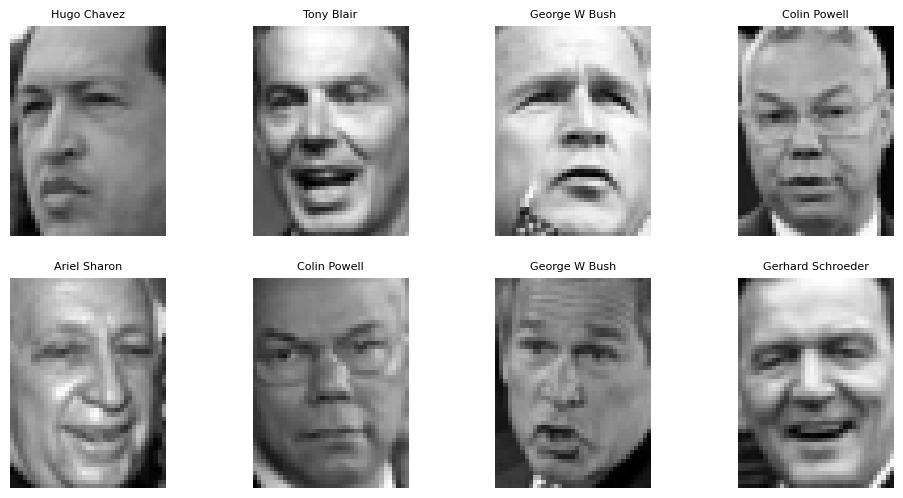

In [28]:
plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title(target_names[y[i]], fontsize=8)
    plt.axis('off')

plt.show()

In [29]:
# Normalize
X = X / 255.0

# Convert grayscale to RGB
X = np.stack((X, X, X), axis=-1)

# Resize images
IMG_SIZE = 96
X = tf.image.resize(X, (IMG_SIZE, IMG_SIZE)).numpy()

print(X.shape)

(1288, 96, 96, 3)


In [30]:
y = to_categorical(y)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

print(X_train.shape)
print(X_test.shape)

(1030, 96, 96, 3)
(258, 96, 96, 3)


In [32]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [33]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(y.shape[1], activation='softmax')

])

In [34]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [35]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

In [36]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=30,

    batch_size=32,

    callbacks=[early_stop]

)

Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 328ms/step - accuracy: 0.3580 - loss: 1.8732 - val_accuracy: 0.4272 - val_loss: 1.6991
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 225ms/step - accuracy: 0.3847 - loss: 1.7716 - val_accuracy: 0.4272 - val_loss: 1.6934
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.3968 - loss: 1.7572 - val_accuracy: 0.4272 - val_loss: 1.6907
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step - accuracy: 0.4041 - loss: 1.7455 - val_accuracy: 0.4272 - val_loss: 1.7045
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step - accuracy: 0.4102 - loss: 1.7348 - val_accuracy: 0.4272 - val_loss: 1.6897
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step - accuracy: 0.4005 - loss: 1.7318 - val_accuracy: 0.4272 - val_loss: 1.7046
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - accuracy: 0.4005 - loss: 1.7153 - val_accuracy: 0.4272 - val_loss: 1.7030
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step - accuracy: 0.4017 - loss: 1.7397 - val_accuracy: 

In [37]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 352ms/step - accuracy: 0.4109 - loss: 1.6951
Test Accuracy: 0.41085270047187805


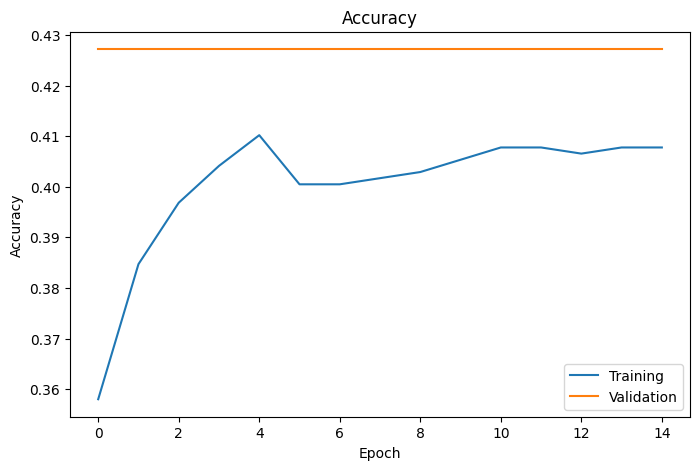

In [38]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training')

plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy")

plt.legend()

plt.show()

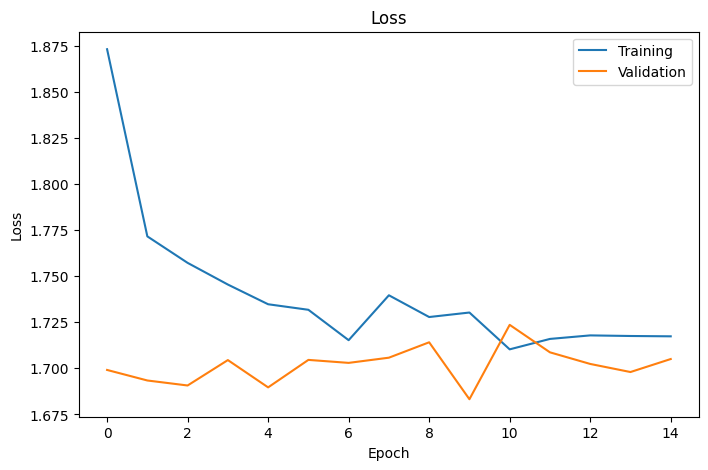

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training')

plt.plot(history.history['val_loss'], label='Validation')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss")

plt.legend()

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 299ms/step


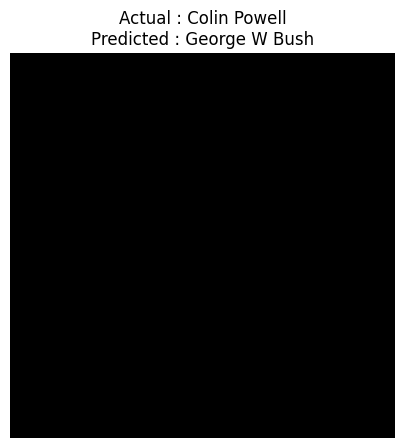

In [40]:
pred = np.argmax(model.predict(X_test), axis=1)

true = np.argmax(y_test, axis=1)

plt.figure(figsize=(5,5))

plt.imshow(X_test[0])

plt.title(f"Actual : {target_names[true[0]]}\nPredicted : {target_names[pred[0]]}")

plt.axis('off')

plt.show()

In [41]:
print(classification_report(

    true,

    pred,

    target_names=target_names

))

                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        16
     Colin Powell       0.00      0.00      0.00        47
  Donald Rumsfeld       0.00      0.00      0.00        24
    George W Bush       0.41      1.00      0.58       106
Gerhard Schroeder       0.00      0.00      0.00        22
      Hugo Chavez       0.00      0.00      0.00        14
       Tony Blair       0.00      0.00      0.00        29

         accuracy                           0.41       258
        macro avg       0.06      0.14      0.08       258
     weighted avg       0.17      0.41      0.24       258



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


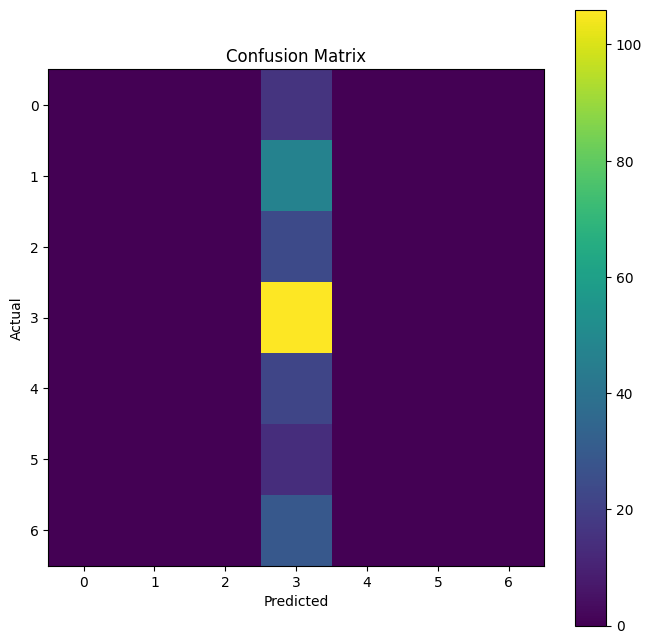

In [42]:
cm = confusion_matrix(true, pred)

plt.figure(figsize=(8,8))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [43]:
model.save("LFW_Face_Recognition_Model.keras")